In [20]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous


# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First let us construct a regular PBC hamiltonian on our lattice, using all the methods from amorphous_mean_field

In [64]:
# generate the lattice and set the initial conditions

import koala.graph_utils

# create lattice
system_length = 10
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])

# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
Js = np.linspace(0.,0.5,11)  # Interaction strength
filling = 0.2  # filling of the lattice
theta_offset = np.pi/4 #global rotation of the orbitals

tol_mdiff = 1e-3
n_fock_steps = 300  # number of Hartree-Fock steps
lead_symmetry = np.diag([-1,-1,1,1])

results = []

for J in Js:
    initial_m = np.full(lattice.n_vertices, 1)  # initial magnetization
    initial_parameters = {
        "t1": t1,
        "t2": t2,
        "J": J,
        "filling": filling,
        "initial_m": initial_m,
        "theta_offset": theta_offset
    }


    m_values = hartree_fock(lattice, initial_parameters, n_fock_steps,tol_mdiff=1e-2)

    # make ham and solve
    hamiltonian = alt_hamiltonian(
        lattice,
        initial_parameters["t1"],
        initial_parameters["t2"],
        initial_parameters["J"],
        m_values[-1],
        theta_offset = initial_parameters['theta_offset']
    )
    energies, states = la.eigh(hamiltonian)

    results.append(dict(initial_m=initial_m,initial_parameters=initial_parameters,m_values=m_values,lattice=lattice))



Avg:0.79, diff: 0.007824:   7%|▋         | 20/300 [00:01<00:15, 18.46it/s]


Text(0.5, 1.0, 'Magnetisation')

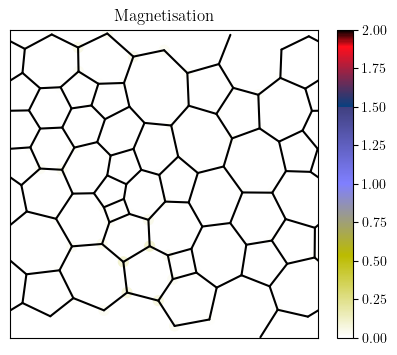

In [65]:
# plot that shit for one J
idx = 5
J = Js[idx]
m_values = results[idx]['m_values']

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
pl.plot_edges(lattice, ax=ax)
im = ax.scatter(
    lattice.vertices.positions[:, 0],
    lattice.vertices.positions[:, 1],
    c=m_values[-1],
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=2,
)
plt.colorbar(im, ax=ax)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Magnetisation")
# print(lattice)




In [66]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

for result in results:

    hamiltonian = alt_hamiltonian(
        result['lattice'],
        result['initial_parameters']["t1"],
        result['initial_parameters']["t2"],
        result['initial_parameters']["J"],
        result['m_values'][-1],
    )

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, lead_symmetry
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
    result['spin_cond'] = g

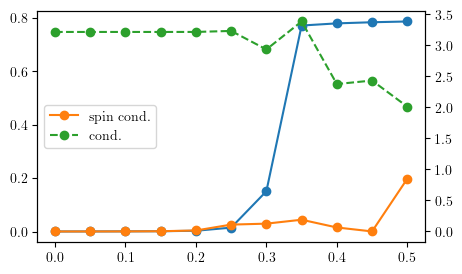

In [67]:
g_spin = np.abs([result['spin_cond'][0,0]-result['spin_cond'][1,1] for result in results])
g = np.abs([result['spin_cond'][0,0]+result['spin_cond'][1,1] for result in results])

m_avg = [result['m_values'][-1].mean() for result in results]

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
axL = ax.twinx()
ax.plot(Js,m_avg,'-o',color='tab:blue',label='avg. magnetization')
axL.plot(Js,g_spin,'-o',color='tab:orange',label='spin cond.')
axL.plot(Js,g,'--o',color='tab:green',label='cond.')

axL.legend()

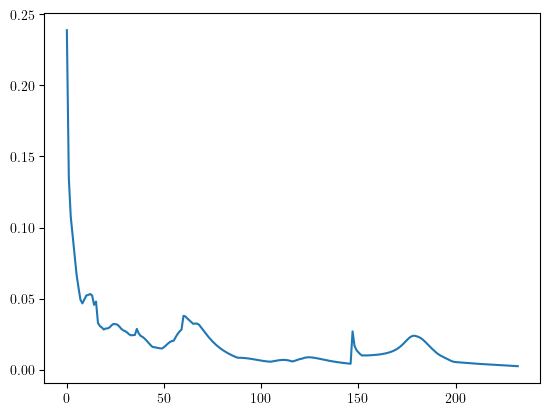

In [59]:
# plot that shit for one J

idx = 5
J = Js[idx]
m_values = results[idx]['m_values'] #.shape = (iterations,sites)
m_diff = np.abs(m_values[1:]-m_values[:-1])

fig,ax = plt.subplots()
#ax.plot(m_values.mean(axis=1),'-')
ax.plot(np.arange(0,m_diff.shape[0]),m_diff.max(axis=1))
#ax.set_yscale('log')